In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
sales=pd.read_csv("C:/sales_data.csv",engine="python",encoding="latin-1")

In [8]:
sales.head()

,Row ID,Order_ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order_ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product_Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
sales.isnull().sum()

Row ID           0
Order_ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"], format="mixed")

In [12]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order_ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## VISUALIZATION

## HISTOGRAM

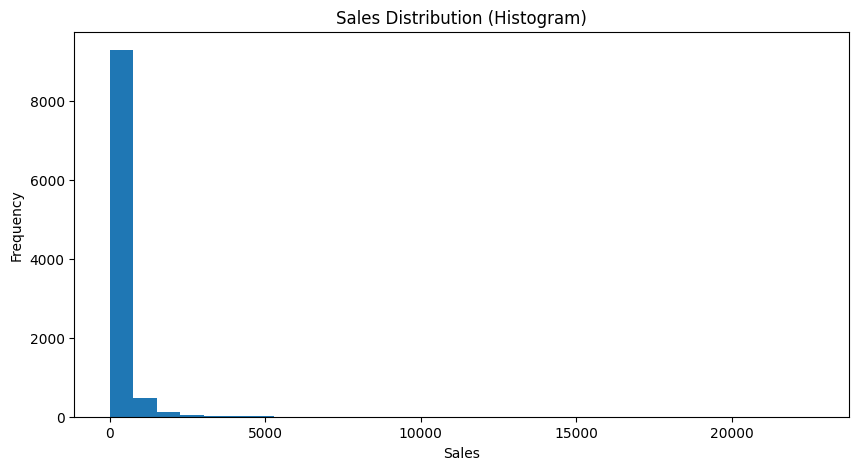

In [16]:
plt.figure(figsize=(10,5))
plt.hist(sales["Sales"], bins=30)
plt.title("Sales Distribution (Histogram)")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.savefig("histogram_sales.png")
plt.show()

## KDE Plot

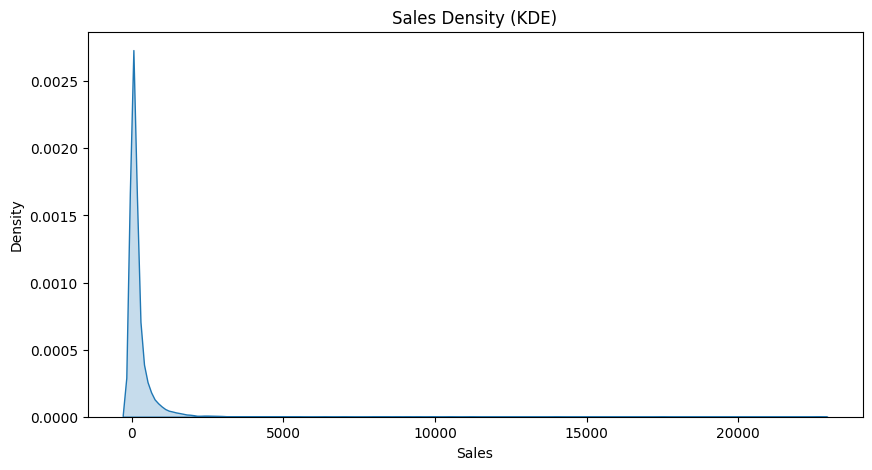

In [19]:
plt.figure(figsize=(10,5))
sns.kdeplot(sales["Sales"], fill=True)
plt.title("Sales Density (KDE)")
plt.xlabel("Sales")
plt.savefig("kde_sales.png")
plt.show()

## BoxPlot

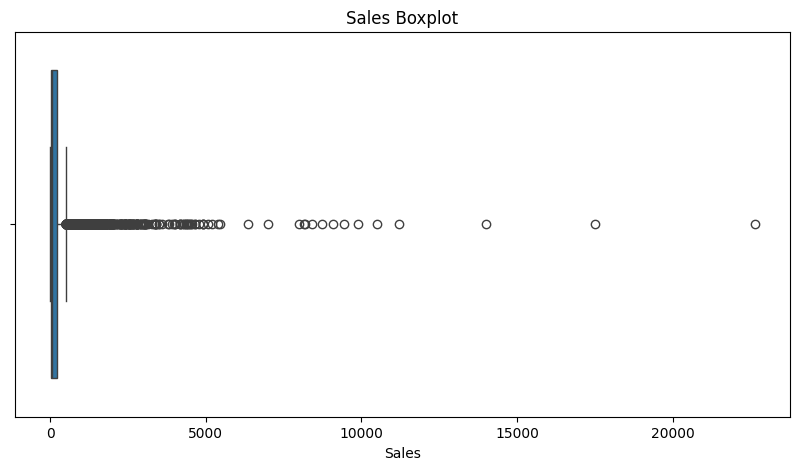

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x=sales["Sales"])
plt.title("Sales Boxplot")
plt.savefig("boxplot_sales.png")
plt.show()

## Comparing distributions across groups by Region

In [36]:
print(sales["Region"].unique())

['South' 'West' 'Central' 'East']


## Using Boxplot

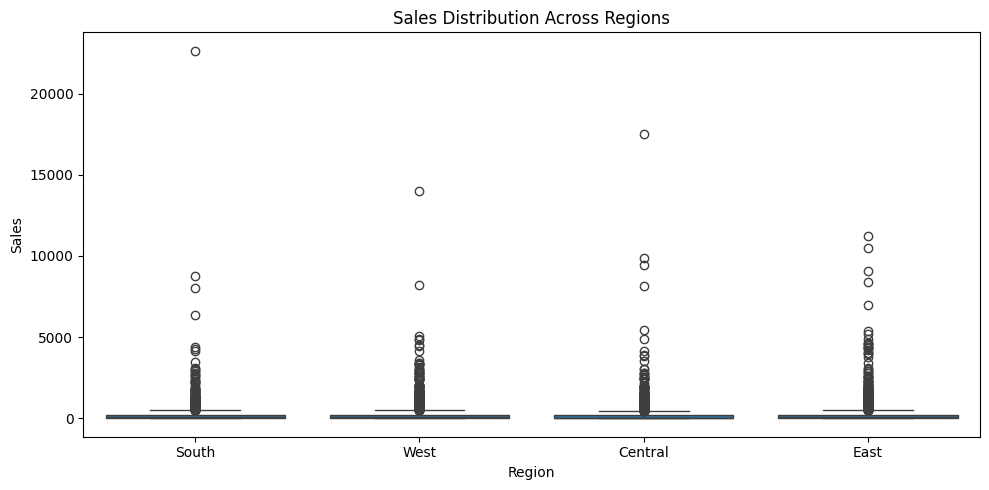

In [49]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Region",y="Sales",data=sales)
plt.title("Sales Distribution Across Regions")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("boxplot_region_sales.png")
plt.show()

## Using KDEplot

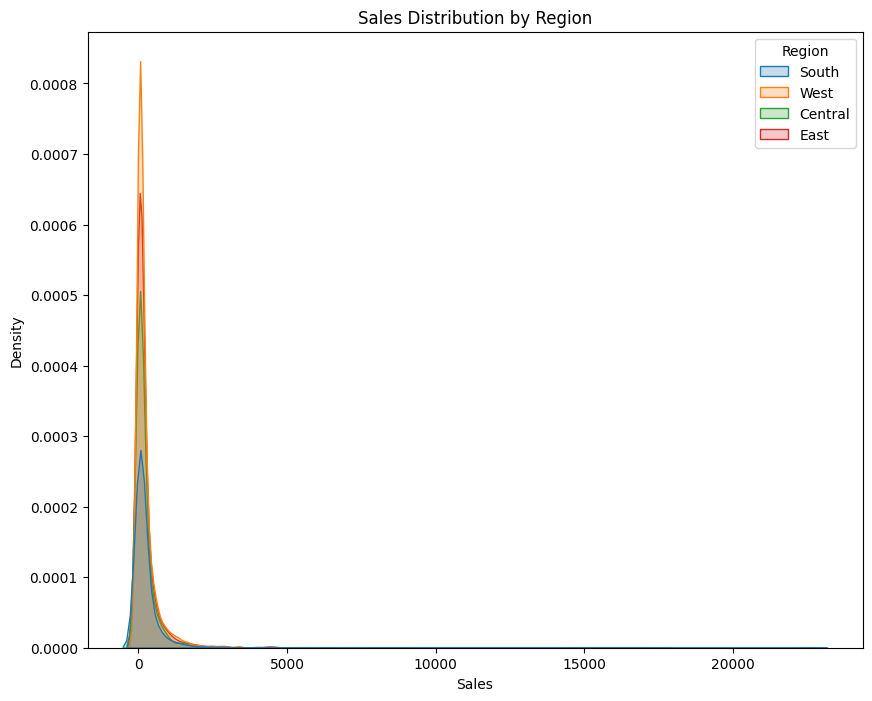

In [33]:
plt.figure(figsize=(10,8))
sns.kdeplot(data=sales, x="Sales", hue="Region", fill=True)
plt.title("Sales Distribution by Region")
plt.xlabel("Sales")
plt.savefig("kde_region_sales.png")
plt.show()

Sales distribution varies across regions. Some regions show higher median sales and wider spread, indicating greater variability in transactions. The presence of outliers suggests that certain regions have unusually high sales values compared to others.

## Detecting Outliers

In [37]:
Q1=sales["Sales"].quantile(0.25)
Q3=sales["Sales"].quantile(0.75)
IQR=Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = sales[(sales["Sales"] < lower_bound) | (sales["Sales"] > upper_bound)]
print("Number of outliers:", len(outliers))

Number of outliers: 1167


## Visual confirmation (Boxplot)

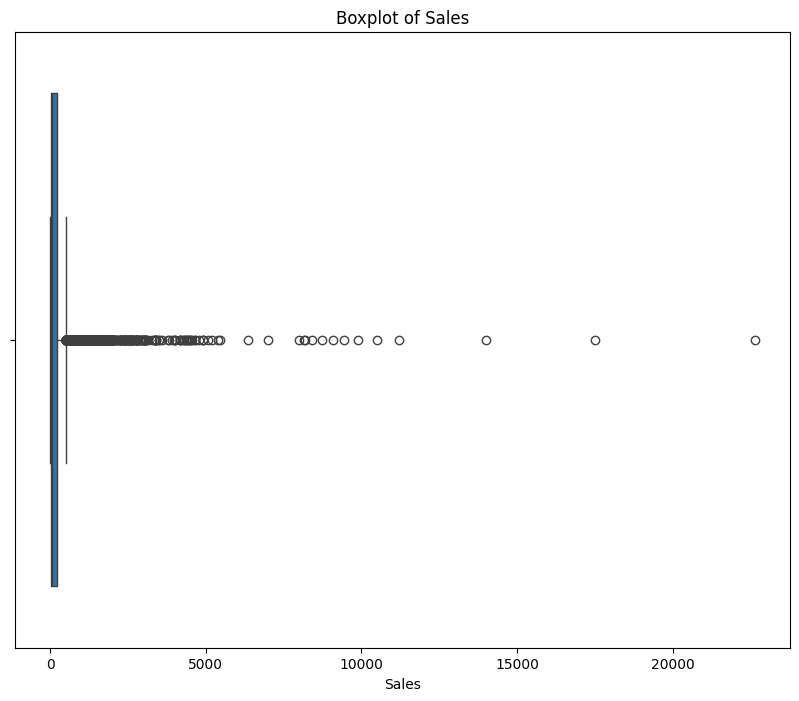

In [40]:
plt.figure(figsize=(10,8))
sns.boxplot(x=sales["Sales"])
plt.title("Boxplot of Sales")
plt.savefig("boxplot_sales.png")
plt.show()

## Detecting Skewness

In [41]:
print("Skewness:", sales["Sales"].skew())

Skewness: 12.97275234181623


The sales data is highly positively skewed, with a skewness value of approximately 12.97. This indicates that most sales values are concentrated at lower ranges, while a few extremely high values create a long right tail.The presence of these high-value outliers significantly affects the distribution, making it non-symmetric and heavily skewed.

## Spread

In [43]:
print("Mean:",sales["Sales"].mean())
print("Median:",sales["Sales"].median())
print("Standard Deviation:",sales["Sales"].std())

Mean: 229.85800083049827
Median: 54.489999999999995
Standard Deviation: 623.2451005086808


Outliers were detected in the Sales data using the IQR method. A number of values lie beyond the upper bound, indicating unusually high sales transactions.
The distribution of sales is positively skewed (right-skewed), as most values are concentrated at lower ranges with a few high-value outliers.
The spread of the data is relatively wide, as indicated by the standard deviation, showing significant variation in sales values across transactions.

### Summary

In [45]:
interpretation = """
The sales distribution is highly positively skewed, with most values concentrated at lower ranges and a few extremely high values forming a long right tail. The histogram and KDE plot confirm this uneven distribution, while the boxplot clearly highlights the presence of significant outliers. The high skewness indicates that a small number of large transactions contribute disproportionately to overall sales, resulting in a wide spread of data.
"""
with open("project2_summary.txt", "w") as f:
    f.write(interpretation)

In [47]:
print(interpretation)


The sales distribution is highly positively skewed, with most values concentrated at lower ranges and a few extremely high values forming a long right tail. The histogram and KDE plot confirm this uneven distribution, while the boxplot clearly highlights the presence of significant outliers. The high skewness indicates that a small number of large transactions contribute disproportionately to overall sales, resulting in a wide spread of data.

